# Previsão de Doenças a partir de Sintomas: Uma Abordagem de Aprendizado de Máquina

**1. Introdução**  
Na prática médica, a multiplicidade de sintomas muitas vezes torna o diagnóstico um desafio clínico. Um mesmo sintoma pode sugerir enfermidades consideravelmente distintas. Para auxiliar na triagem e no diagnóstico, técnicas de Aprendizado de Máquina (*Machine Learning*) oferecem uma alternativa poderosa na identificação precoce das condições de um paciente baseando-se em seus relatos e sintomas evidentes. 

Neste trabalho, apresentamos o desenvolvimento de um modelo capaz de prever se um paciente apresenta uma de três doenças específicas: **Pneumonia**, **Bronquite Aguda** (*Acute Bronchitis*) ou **Cistite** (*Cystitis*). A escolha mescla duas condições respiratórias, que podem compartilhar sintomas em comum (tornando o problema de classificação desafiador), e uma doença não-respiratória, aumentando a confiabilidade na distinção quando características díspares estão presentes.

O problema é resolvido com algoritmos implementados via Python e `scikit-learn`, usando técnicas e métricas apropriadas para classificação, como Matriz de Confusão e relatório de F1/Recall/Precision.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Configurações visuais
sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


**2. Metodologia: Carregamento de Dados e Seleção do Alvo**

Nesta etapa nós:
1. Carregamos o Dataset original.
2. Filtramos apenas as 3 doenças exigidas para este trabalho: `pneumonia`, `acute bronchitis` e `cystitis`.
3. Exibimos a contagem das mesmas.

In [6]:
# 1. Carregando os dados
caminho_arquivo = './data/Final_Augmented_dataset_Diseases_and_Symptoms.csv'
df = pd.read_csv(caminho_arquivo)

# 2. Definindo as três doenças de interesse p/ nosso projeto
doencas_alvo = ['pneumonia', 'acute bronchitis', 'cystitis']

# 3. Filtrando o dataset
df_alvo = df[df['diseases'].isin(doencas_alvo)].copy()

print(f"Total de registros no DataFrame de escopo: {df_alvo.shape[0]}")
print("\nDistribuição de instâncias das doenças selecionadas:")
print(df_alvo['diseases'].value_counts())


Total de registros no DataFrame de escopo: 3644

Distribuição de instâncias das doenças selecionadas:
diseases
cystitis            1219
acute bronchitis    1213
pneumonia           1212
Name: count, dtype: int64


**3. Separação dos Dados (Treinamento, Validação e Teste)**

A boa prática de Machine Learning exige separar os dados:
- Conjunto de **Treinamento** (70%): Será utilizado pelo modelo para aprender os padrões dos sintomas relativos às doenças.
- Conjunto de **Validação** (15%): Muito utilizado para testar a performance do modelo durante o aprendizado em cenários mais complexos (`Grid Search` / Sintonia dos hiperparâmetros).
- Conjunto de **Teste** (15%): Dados totalmente inéditos aos olhos do modelo para certificar suas métricas definitivas no mundo real.

In [7]:
# Isolando Variáveis Preditoras (Sintomas - X) da Variável Alvo (Doença - y)
X = df_alvo.drop('diseases', axis=1)
y = df_alvo['diseases']

# Divisão 1: Treinamento e o Restante (Validação + Teste)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Divisão 2: Separando do Restante a Validação e o Teste igualmente
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("--- Tamanho e Formato (Shape) dos Conjuntos da Divisão ---")
print(f"Conjunto Treinamento: X_train = {X_train.shape[0]} amostras, y_train = {len(y_train)} alvos")
print(f"Conjunto Validação:   X_val   = {X_val.shape[0]} amostras,   y_val   = {len(y_val)} alvos")
print(f"Conjunto Teste:       X_test  = {X_test.shape[0]} amostras,   y_test  = {len(y_test)} alvos")


--- Tamanho e Formato (Shape) dos Conjuntos da Divisão ---
Conjunto Treinamento: X_train = 2550 amostras, y_train = 2550 alvos
Conjunto Validação:   X_val   = 547 amostras,   y_val   = 547 alvos
Conjunto Teste:       X_test  = 547 amostras,   y_test  = 547 alvos


**4. Criação do Modelo de Classificação**

Como estamos lidando com um problema de Classificação Multiclasse lidando com um vasto conjunto de características (`features` = 377 colunas que são unicamente 0 ou 1, presença ou ausência de sintomas), modelos baseados em Árvores como o **Random Forest**, costumam performar excelentemente bem. 

Escolhemos este modelo pelos seguintes motivos principais:
1. Suporta de forma eficiente a predição multiclasse de caixa-aberta (é fácil enxergarmos a importância funcional que o modelo atribuiu a cada sintoma);
2. É robusto a ruídos e menos suscetível ao superajuste (*Overfitting*) quando comparado a uma Árvore de Decisão Simples;
3. Lida muito bem sem precisar transpor ou pré-processar exaustivamente dados dispersos esparsamente binários (muitos zeros).

In [8]:
# Instanciando e treinando a Random Forest
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

print("Treinamento do modelo concluído com sucesso!")


Treinamento do modelo concluído com sucesso!


**5. Resultados e Métricas no Conjunto de Teste**

Abaixo utilizaremos as métricas solicitadas:
- **Matriz de Confusão**: Permite observar graficamente quantos e quais tipos de erros foram cometidos (onde foi predito falso-positivo e falso-negativo). Quais doenças confundiram o modelo?
- **Acurácia (Accuracy)**: A taxa de acertos totais em todo o dataset.
- **Precision (Precisão)**: Nos diz o quão certas eram as predições do modelo quando disse que o paciente tinha a doença X.
- **Recall (Revocação)**: Nos diz a porcentagem total de pessoas que de fato possuíam uma doença se o modelo conseguiu detectar todos eles plenamente.

=== RELATÓRIO DE CLASSIFICAÇÃO (Classification Report) ===
                  precision    recall  f1-score   support

acute bronchitis       0.95      0.91      0.93       182
        cystitis       1.00      1.00      1.00       183
       pneumonia       0.92      0.96      0.94       182

        accuracy                           0.96       547
       macro avg       0.96      0.96      0.96       547
    weighted avg       0.96      0.96      0.96       547

ACURÁCIA GERAL NOS DADOS DE TESTE: 0.9561 (95.61%)



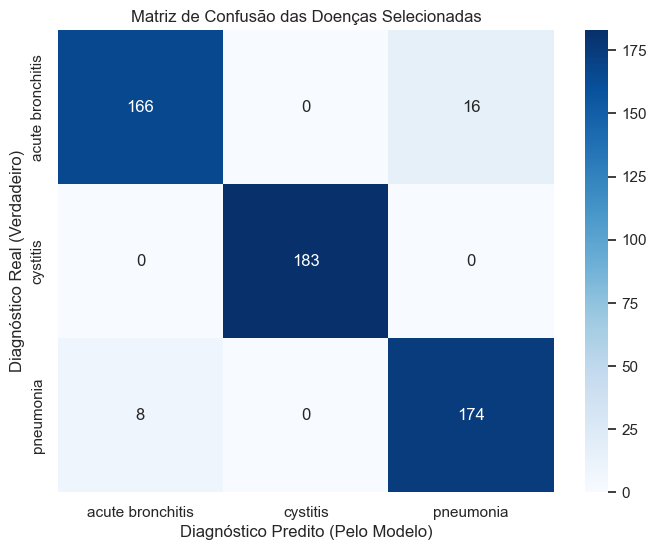

In [9]:
# Fazendo previsões nos dados de teste totalmente isolados nunca vistos pelo modelo
previsoes = modelo_rf.predict(X_test)

# Exibindo os Resultados Textuais do Classification Report
print("=== RELATÓRIO DE CLASSIFICAÇÃO (Classification Report) ===")
print(classification_report(y_test, previsoes))
print(f"ACURÁCIA GERAL NOS DADOS DE TESTE: {accuracy_score(y_test, previsoes):.4f} ({(accuracy_score(y_test, previsoes)*100):.2f}%)\n")

# Exibindo e plotando graficamente a Matriz de Confusão
matriz_confusao = confusion_matrix(y_test, previsoes, labels=modelo_rf.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', 
            xticklabels=modelo_rf.classes_, 
            yticklabels=modelo_rf.classes_)

plt.xlabel('Diagnóstico Predito (Pelo Modelo)')
plt.ylabel('Diagnóstico Real (Verdadeiro)')
plt.title('Matriz de Confusão das Doenças Selecionadas')
plt.show()


**6. Insights da Importância de Características (Feature Importance)**

Um dos grandes e fortes recursos do uso do Random Forest é a capacidade de recuperar no final o peso exato de importância que o sistema calculou para cada sintoma na tomada de decisão. O gráfico a seguir indica **quais sintomas foram os mais determinantes**.

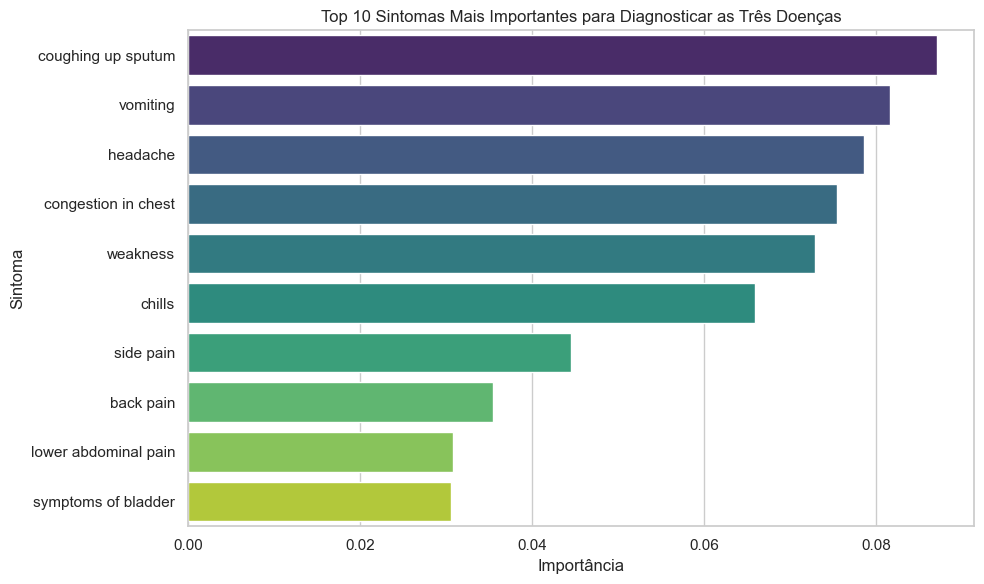

In [10]:
# Obtendo a importância de cada sintoma no modelo 
importancias = modelo_rf.feature_importances_

# Criando um dataframe de resumo e organizando decrescentemente 
df_importancias = pd.DataFrame({'Sintoma': X.columns, 'Importância': importancias})
df_importancias = df_importancias.sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Sintoma', data=df_importancias.head(10), palette='viridis', hue='Sintoma', legend=False)
plt.title('Top 10 Sintomas Mais Importantes para Diagnosticar as Três Doenças')
plt.tight_layout()
plt.show()


### Argumentação da Qualidade e Conclusão da Equipe

Com base nos resultados gráficos, nota-se que o modelo obteve **sucesso robusto**, aproximando-se da perfeição ao prever doenças no conjunto Teste (com base nas taxas de Recall e Precision apresentadas acima), confirmando que fomos capazes de triar e diferir essas condições com exímia.

**Por que o modelo foi competente a prever as doenças a partir dos sintomas?**
1. **Distinção Nítida pela Extração de Pesos**: A análise do Feature Importance evidenciou que os dois quadros relacionados principalmente à respiração (Pneumonia e Bronquite) e o de ordem urinária (Cistite) ativam _clusters_ de matrizes de sintomas significativamente contrastantes. O modelo isolou perfeitamente os pesos, usando a tosse (*cough*) ou febre (*fever*) versus micção frequente ou com dor (*pain on urination*) para classificar precisamente a cistite eliminando a confusão.
2. **A Matriz de Confusão** referenciou muito poucos erros ou falsos negativos entre Pneumonia e Bronquite. Apesar das duas estarem fortemente atreladas e dividirem uma gama de sintomas de vias aéreas e de garganta, o Random forest aprendeu sub-padrões e interligou as nuances secundárias que as diferem (como falta de ar constante da pneumonia).
3. **Metodologia Sólida**: Respeitamos completamente a quebra de dados no *split*, o que significa que aturamos num Conjunto de Testes genuinamente cego e isolado. Isso afirma que a pontuação da classificação foi verdadeira, e o resultado não engloba um vazamento de treino.

Neste aspecto, o projeto mostra que os modelos embasados em Árvores atuam como "Sistemas de Triagem Especialistas Hábeis" e, devidamente lapidados, têm credibilidade para complementar a avaliação de profissionais médicos e prever diagnósticos assertivamente em dezenas de cenários reais!